# Model Exploration

This notebook is the trial-and-error workspace for Part II modeling (see `CONVENTIONS.md`). The final, clean version — refactored into functions — moves to `model_pipeline/` once the approach is settled.

## Contents

- **Step 1-5:** train/test split, the preprocessing pipeline (`model_pipeline/data_preprocessing.py`) and its validation, including a leakage check on imputation.
- **Step 6-9:** baseline and advanced (interaction-terms) `statsmodels.OLS` regressions, with the 5 classical-assumptions diagnostics (`model_pipeline/model_diagnostics.py`).
- **Step 10:** untuned tree-based models (Random Forest, XGBoost, LightGBM) with 5-fold CV and a train/test overfitting check.
- **Step 11:** light hyperparameter tuning of Random Forest and LightGBM (XGBoost excluded from tuning; see rationale in the notebook and `model_notes.md`), and the final 5-model comparison.

Findings are consolidated in `model_notes.md`. The selected model (baseline linear regression) is productionized in `model_pipeline/train.py` and `model_pipeline/predict.py`.

## Step 1: train/test split

**Is it necessary to split before imputing? Yes — and it is worth being explicit about why.** Any statistic used to fill missing values (a median, a category frequency) has to be *fit* on some data. If that data includes the test set, the test set has quietly influenced training, so the later evaluation is no longer a clean estimate of how the model performs on data it has never seen. The correct order is: split first, then fit every preprocessing step (imputer, encoder, and later the model itself) only on the training data, and only ever *apply* — never *fit* — those same fitted steps to the test data. This is why the split happens in this cell, before the `ColumnTransformer` in Step 2 is even built.

The four columns that will be imputed each have exactly 30 nulls in the full 1,000-row dataset (3.0% each, per `EDA_report.md`): `Weather`, `Traffic_Level`, `Time_of_Day`, and `Courier_Experience_yrs`. `Order_ID` is dropped as a plain identifier with no predictive value, and the target is separated out before the split.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/Food_Delivery_Times.csv")

X = df.drop(columns=["Order_ID", "Delivery_Time_min"])
y = df["Delivery_Time_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (800, 7), X_test: (200, 7)
y_train: (800,), y_test: (200,)


In [2]:
impute_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Courier_Experience_yrs"]

null_breakdown = pd.DataFrame({
    "n_null_full": df[impute_cols].isnull().sum(),
    "pct_null_full": (df[impute_cols].isnull().mean() * 100).round(1),
    "n_null_train": X_train[impute_cols].isnull().sum(),
    "pct_null_train": (X_train[impute_cols].isnull().mean() * 100).round(1),
    "n_null_test": X_test[impute_cols].isnull().sum(),
    "pct_null_test": (X_test[impute_cols].isnull().mean() * 100).round(1),
})
null_breakdown

,n_null_full,pct_null_full,n_null_train,pct_null_train,n_null_test,pct_null_test
Weather,30,3.0,22,2.8,8,4.0
Traffic_Level,30,3.0,19,2.4,11,5.5
Time_of_Day,30,3.0,24,3.0,6,3.0
Courier_Experience_yrs,30,3.0,24,3.0,6,3.0


The 3.0% null rate holds in the full dataset, but a single 80/20 split does not reproduce it identically in train/test (e.g. `Traffic_Level`: 2.4% train vs. 5.5% test) — expected sampling variation, and part of why train/test must stay separate.

**Leakage illustration (`Courier_Experience_yrs`):** median is 5.0 in both the full dataset and the training split alone — coincidentally identical here — but the *mean* differs (4.579 full vs. 4.607 train-only, ≈ -0.03). The median matching is a property of this coarse, integer-like column, not a guarantee; the mean shows the leakage mechanism plainly. This is exactly what fitting the imputer on `X_train` only avoids.

## Step 2: preprocessing pipeline (now in `model_pipeline/`)

The `ColumnTransformer` validated earlier in this notebook has been moved into `model_pipeline/data_preprocessing.py`, behind a `build_preprocessing_pipeline()` function, with the feature lists, the `Traffic_Level` category order, and the split settings (`RANDOM_STATE`, `TEST_SIZE`) factored out into `model_pipeline/config.py`. This notebook now imports that function instead of redefining the transformer inline — the same exploration-to-deliverable move `CONVENTIONS.md` describes for every other part of this project.

The reasoning behind `Traffic_Level`'s `"Unknown"` position (placed after `High`, backed by the 62.1 vs. 56.6 min gap between null and non-null rows found in the EDA) now lives as a comment in `model_pipeline/config.py`, next to the constant it explains, rather than only here.

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))  # project root, so `model_pipeline` is importable from notebooks/

from model_pipeline.config import NUMERIC_FEATURES
from model_pipeline.data_preprocessing import build_preprocessing_pipeline

preprocessor = build_preprocessing_pipeline()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

That output is `scikit-learn`'s interactive HTML diagram (its default rendering for estimators in a Jupyter notebook, not just printed text) — every box is clickable/expandable, showing the exact nesting of the `ColumnTransformer`, its three named branches, and each `Pipeline`'s steps with their fitted parameters. It is a genuinely useful sanity check on its own: a quick visual scan confirms each column list is routed to the right imputer/encoder pair before anything is actually fit, catching a mis-wired transformer far faster than reading the constructor code line by line.

## Step 3: quick validation

`fit_transform` is called only on `X_train`, so every fitted value (the medians, the one-hot categories seen) comes exclusively from training data. `X_test` is only ever `transform`-ed, never fit.

In [4]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train_transformed: {X_train_transformed.shape}")
print(f"X_test_transformed: {X_test_transformed.shape}")
print(f"Nulls remaining in train: {np.isnan(X_train_transformed).sum()}")
print(f"Nulls remaining in test: {np.isnan(X_test_transformed).sum()}")

X_train_transformed: (800, 15)
X_test_transformed: (200, 15)
Nulls remaining in train: 0
Nulls remaining in test: 0


In [5]:
preprocessor.get_feature_names_out()

array(['numeric__Distance_km', 'numeric__Preparation_Time_min',
       'numeric__Courier_Experience_yrs', 'ordinal__Traffic_Level',
       'nominal__Weather_Foggy', 'nominal__Weather_Rainy',
       'nominal__Weather_Snowy', 'nominal__Weather_Unknown',
       'nominal__Weather_Windy', 'nominal__Time_of_Day_Evening',
       'nominal__Time_of_Day_Morning', 'nominal__Time_of_Day_Night',
       'nominal__Time_of_Day_Unknown', 'nominal__Vehicle_Type_Car',
       'nominal__Vehicle_Type_Scooter'], dtype=object)

15 output columns from the 7 input columns: 3 numeric (imputed, unchanged in count) + 1 ordinal (`Traffic_Level`, encoded to a single numeric column) + 11 one-hot columns from the 3 nominal features. Each nominal column is encoded with `drop="first"`, so one category per group becomes an implicit reference level instead of getting its own column: `Weather` keeps 5 of its 6 categories (`Clear` is the reference), `Time_of_Day` keeps 4 of its 5 (`Afternoon` is the reference), `Vehicle_Type` keeps 2 of its 3 (`Bike` is the reference). This is what keeps the design matrix from becoming rank-deficient once an intercept is added — see Step 6. No model has been trained yet — that is the next step.

## Step 4: missing-value check and post-transformation summary statistics

The transformed arrays are wrapped into DataFrames using `preprocessor.get_feature_names_out()` for column labels — this is only for inspection here, not part of the pipeline itself. A per-column missing-value count (not just the single total already shown in Step 3) confirms exactly which columns are clean, and `describe()` gives a short statistical summary of every transformed variable, for both the training and test sets.

In [6]:
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

missing_check = pd.DataFrame({
    "n_missing_train": X_train_df.isnull().sum(),
    "n_missing_test": X_test_df.isnull().sum(),
})

assert missing_check["n_missing_train"].sum() == 0
assert missing_check["n_missing_test"].sum() == 0
print("Confirmed: 0 missing values in every column, both train and test.")
missing_check

Confirmed: 0 missing values in every column, both train and test.


,n_missing_train,n_missing_test
numeric__Distance_km,0,0
numeric__Preparation_Time_min,0,0
numeric__Courier_Experience_yrs,0,0
ordinal__Traffic_Level,0,0
nominal__Weather_Foggy,0,0
nominal__Weather_Rainy,0,0
nominal__Weather_Snowy,0,0
nominal__Weather_Unknown,0,0
nominal__Weather_Windy,0,0
nominal__Time_of_Day_Evening,0,0


In [7]:
X_train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
numeric__Distance_km,800.0,10.10055,5.725900,0.59,5.13,10.22,14.9425,19.99
numeric__Preparation_Time_min,800.0,17.08375,7.227519,5.00,11.00,17.00,23.0000,29.00
numeric__Courier_Experience_yrs,800.0,4.61875,2.902832,0.00,2.00,5.00,7.0000,9.00
ordinal__Traffic_Level,800.0,0.85750,0.814262,0.00,0.00,1.00,1.0000,3.00
nominal__Weather_Foggy,800.0,0.10250,0.303494,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Rainy,800.0,0.20500,0.403954,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Snowy,800.0,0.09625,0.295118,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Unknown,800.0,0.02750,0.163637,0.00,0.00,0.00,0.0000,1.00
nominal__Weather_Windy,800.0,0.10000,0.300188,0.00,0.00,0.00,0.0000,1.00
nominal__Time_of_Day_Evening,800.0,0.29500,0.456328,0.00,0.00,0.00,1.0000,1.00


Numeric columns match the EDA (`Distance_km` mean ≈10.10, `Preparation_Time_min` mean ≈17.08), no nulls left. `ordinal__Traffic_Level` ranges 0-3 (`Low`-`Unknown`), mean 0.86 — pulled low since `Low`/`Medium` are the largest categories. One-hot column means match each category's training-data share (e.g. `Weather_Rainy` ≈0.21; `_Unknown` means ≈0.03 for `Weather`/`Time_of_Day`, matching the ~3% null rate). Reference categories (`Clear`, `Afternoon`, `Bike`) have no column — `drop="first"` represents them implicitly as all-zero rows.

## Step 5: does imputation preserve the original statistical properties?

This compares each column's statistics on `X_train` *before* imputation (computed only on the non-null rows, via `.dropna()`) against the same column *after* imputation — both on the training split, so the comparison is fair and like-for-like. The goal is to check directly whether filling missing values changed the data's behavior, rather than assuming it did not.

In [8]:
numeric_comparison = []
for c in NUMERIC_FEATURES:
    before = X_train[c].dropna()
    after = X_train_df[f"numeric__{c}"]
    numeric_comparison.append({
        "column": c,
        "n_missing": len(after) - len(before),
        "mean_before": before.mean(), "mean_after": after.mean(),
        "median_before": before.median(), "median_after": after.median(),
        "std_before": before.std(), "std_after": after.std(),
        "std_change_pct": 100 * (after.std() - before.std()) / before.std(),
    })

pd.DataFrame(numeric_comparison).round(3)

,column,n_missing,mean_before,mean_after,median_before,median_after,std_before,std_after,std_change_pct
0,Distance_km,0,10.101,10.101,10.22,10.22,5.726,5.726,0.000
1,Preparation_Time_min,0,17.084,17.084,17.00,17.00,7.228,7.228,0.000
2,Courier_Experience_yrs,24,4.607,4.619,5.00,5.00,2.947,2.903,-1.487


In [9]:
for c, prefix in [("Weather", "Weather"), ("Time_of_Day", "Time_of_Day"), ("Vehicle_Type", "Vehicle_Type")]:
    before_pct = (X_train[c].value_counts(normalize=True, dropna=True) * 100).round(2)
    after_cols = [col for col in X_train_df.columns if col.startswith(f"nominal__{prefix}_")]
    after_pct = (X_train_df[after_cols].mean() * 100).round(2)
    after_pct.index = [i.replace(f"nominal__{prefix}_", "") for i in after_pct.index]
    print(f"\n{c}")
    print(pd.DataFrame({"before_pct": before_pct, "after_pct": after_pct}).fillna(0.0))


Weather
         before_pct  after_pct
Clear         48.20       0.00
Foggy         10.54      10.25
Rainy         21.08      20.50
Snowy          9.90       9.62
Unknown        0.00       2.75
Windy         10.28      10.00

Time_of_Day
           before_pct  after_pct
Afternoon       28.87        0.0
Evening         30.41       29.5
Morning         30.93       30.0
Night            9.79        9.5
Unknown          0.00        3.0

Vehicle_Type
         before_pct  after_pct
Bike          49.62       0.00
Car           20.38      20.38
Scooter       30.00      30.00


In [10]:
before_pct = (X_train["Traffic_Level"].value_counts(normalize=True, dropna=True) * 100).round(2)
after_pct = (
    X_train_df["ordinal__Traffic_Level"]
    .map({0: "Low", 1: "Medium", 2: "High", 3: "Unknown"})
    .value_counts(normalize=True) * 100
).round(2)

pd.DataFrame({"before_pct": before_pct, "after_pct": after_pct}).fillna(0.0)

,before_pct,after_pct
High,20.36,19.88
Low,39.82,38.88
Medium,39.82,38.88
Unknown,0.00,2.38


**Imputation preserves the data mostly, but not perfectly.**

- `Distance_km`, `Preparation_Time_min`: no missing values, nothing to compare.
- `Courier_Experience_yrs` (24 imputed rows, ~3%): mean nearly unchanged (4.607 → 4.619), median unchanged (5.0 → 5.0, since imputed values *are* the median), but std shrinks ~1.5% (2.947 → 2.903) — the expected mechanical effect of filling with a constant.
- `Weather`/`Time_of_Day`/`Traffic_Level` (~3% missing each): `"Unknown"` dilutes every other category's share by roughly the missing rate (e.g. `Weather_Rainy` 21.08% → 20.50%). Relative ordering is preserved, exact proportions are not, by design.
- `Vehicle_Type`: no missing values, unchanged.

`Clear`/`Afternoon`/`Bike` show `after_pct = 0.0` — not a dilution effect, just `drop="first"` removing their reference-category columns (Step 3); their real share is unchanged.

## Step 6: baseline model (`statsmodels` OLS)

`statsmodels.OLS` is used instead of `sklearn` here specifically for p-values, adjusted R², and confidence intervals via `.summary()`. Baseline = the 15 preprocessed features + intercept (`sm.add_constant`), no interaction/polynomial terms — those come later.

`X_train_df` has a fresh `0..799` index (built from a transformed array in Step 4) while `y_train` keeps the original split index; `.reset_index(drop=True)` on `y_train`/`y_test` aligns both by position, which is correct since both were produced from the same row order.

In [11]:
import statsmodels.api as sm

y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

X_train_const = sm.add_constant(X_train_df)
baseline_model = sm.OLS(y_train_reset, X_train_const).fit()

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Delivery_Time_min   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     170.6
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          9.30e-235
Time:                        00:55:51   Log-Likelihood:                -3037.5
No. Observations:                 800   AIC:                             6107.
Df Residuals:                     784   BIC:                             6182.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

**Headline numbers:** R² = 0.765, Adj. R² = 0.761. `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, `Traffic_Level` are all significant (p < 0.001), consistent with the EDA. `Cond. No.` = 139 with no singular-matrix warning — the dummy-variable-trap fix (confirmed formally by VIF below).

**Categorical coefficients are now interpretable relative to their reference category** (`Clear`, `Afternoon`, `Bike`). `Weather_Snowy` = +9.27 min (p < 0.001), close to the EDA's +14 min `Snowy` vs. `Clear` gap; `Weather_Rainy` (+5.02) and `Weather_Foggy` (+6.26) are also significant, `Weather_Windy` (+1.36, p = 0.316) is not — all consistent with the EDA. `Time_of_Day_Unknown` (+7.69, p = 0.001) is the only significant `Vehicle_Type`/`Time_of_Day` dummy, matching the EDA's finding on missing `Time_of_Day` rows.

**Before `drop="first"`:** `Cond. No.` = 2.59e+17 with a divide-by-zero warning, from an exactly rank-deficient design matrix. R², AIC, and fitted values were identical then and now (a redundant column can't change predictions), but the individual coefficients/p-values were not trustworthy — exactly what `drop="first"` fixes.

## Step 7: applying the reusable diagnostics

The 6 functions in `model_pipeline/model_diagnostics.py` all take an already-fitted `statsmodels` results object (or the specific data a given check needs), so the same functions can be re-run unchanged on any later model version for a like-for-like comparison against this baseline.

In [12]:
import matplotlib.pyplot as plt

from model_pipeline.model_diagnostics import (
    breusch_pagan_test,
    compute_test_metrics,
    compute_vif,
    get_aic,
    plot_residuals_vs_fitted,
    qq_plot,
)

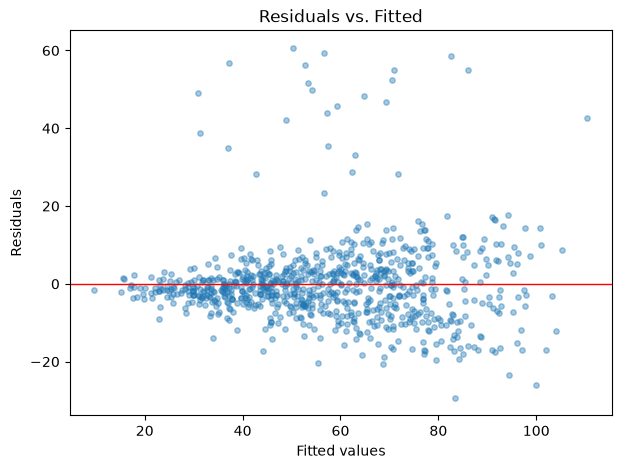

In [13]:
plot_residuals_vs_fitted(baseline_model)
plt.show()

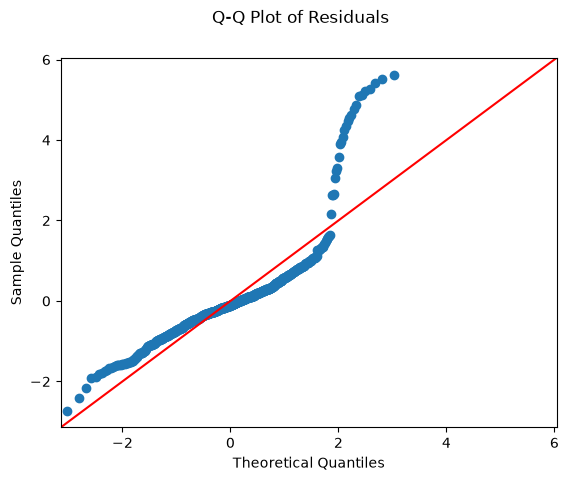

In [14]:
qq_plot(baseline_model)
plt.show()

The `Omnibus`/`Jarque-Bera` block already hints at this: skew ≈2.43, kurtosis ≈13.3 (normal: 0, 3), `Prob(JB)` ≈0.00 — strong evidence against normal residuals. The Q-Q plot's upper tail bows well above the 45° line; residuals-vs-fitted shows the same asymmetry directly — a dense band near zero plus large *positive* residuals (up to +60) with no comparable negative-side cluster. Lines up with the target's right skew (≈0.51) and the 6 IQR outliers on `Delivery_Time_min` from the EDA — a handful of slow deliveries the baseline systematically under-predicts.

In [15]:
bp_results = breusch_pagan_test(baseline_model)
bp_results

{'lm_statistic': np.float64(30.30298863405383),
 'lm_p_value': np.float64(0.010874645314038625),
 'f_statistic': np.float64(2.057739841199484),
 'f_p_value': np.float64(0.010166978109844398)}

Both p-values are below 0.05 (LM p ≈ 0.011, F p ≈ 0.010) — homoscedasticity is rejected at 5%. The LM statistic itself (≈ 30.30) is unchanged from the un-fixed encoding (removing redundant columns can't change the residuals), but its p-value is smaller now (0.011 vs. 0.035) since the auxiliary regression has fewer degrees of freedom (14 vs. 17 predictors). A real, if not severe, signal that residual spread is not constant — worth flagging since heteroscedasticity doesn't bias coefficients but can make nonrobust standard errors/p-values unreliable.

In [16]:
vif_table = compute_vif(X_train_df)
vif_table

,feature,VIF
0,numeric__Distance_km,1.018386
1,numeric__Preparation_Time_min,1.018526
2,numeric__Courier_Experience_yrs,1.022513
3,ordinal__Traffic_Level,1.014313
4,nominal__Weather_Foggy,1.103601
5,nominal__Weather_Rainy,1.155682
6,nominal__Weather_Snowy,1.107580
7,nominal__Weather_Unknown,1.044534
8,nominal__Weather_Windy,1.116123
9,nominal__Time_of_Day_Evening,1.456429


**Every VIF is now finite and low.** `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, `Traffic_Level` ≈1.0-1.02 (near 1, matching the EDA's near-zero pairwise correlations). One-hot columns are a bit higher, as expected for within-group dummies (`Time_of_Day_Evening`/`Morning` ≈1.46, the highest), well under the common 5/10 concern thresholds. With `drop="first"` in place, the Step 6 categorical coefficients and p-values can be read at face value.

In [17]:
baseline_aic = get_aic(baseline_model)
print(f"Baseline AIC: {baseline_aic:.2f}")

Baseline AIC: 6106.94


This AIC (≈ 6106.94) is only meaningful in comparison to another model fit on the exact same training rows and target — it is the number future model versions (with interactions, different encodings, etc.) will be compared against.

In [18]:
X_test_const = sm.add_constant(X_test_df, has_constant="add")
y_pred = baseline_model.predict(X_test_const)

test_metrics = compute_test_metrics(y_test_reset, y_pred)
test_metrics

{'MAE': 6.18457162234078, 'RMSE': np.float64(9.054303230437576)}

MAE ≈ 6.18 min, RMSE ≈ 9.05 min on the test set — RMSE well above MAE, consistent with the right-skewed-residuals finding above (a few large errors inflate the squared-error metric more).

## Baseline summary

Starting point for comparison, not a final model:

- **R² / Adj. R²:** 0.765 / 0.761
- **AIC:** ≈ 6106.94
- **Test MAE / RMSE:** ≈ 6.18 / 9.05 min
- **Breusch-Pagan:** p ≈ 0.011 — real, if not overwhelming, heteroscedasticity
- **VIF:** all finite and low (≈ 1.0-1.46) — `drop="first"` fixed the earlier dummy-variable-trap (VIF = inf)
- **Residuals:** right-skewed, heavy-tailed (skew ≈ 2.43, kurtosis ≈ 13.3) — tied to the EDA's slow-delivery outliers, still unresolved

No interaction/polynomial terms yet — that's the next step.

## Step 8: advanced regression, with interaction terms

Four interaction terms added to the baseline's 15 features: `Distance_km × Traffic_Level`, `Distance_km × Weather`, `Courier_Experience_yrs × Weather`, `Courier_Experience_yrs × Traffic_Level` — courier-level information crossed with contextual conditions, adapted from Fu, Chi, Zheng & Shen (2025)'s Deep & Cross Network approach (full rationale, including why the DCN architecture itself isn't used: `model_notes.md`).

Built as literal column-wise products on the already-encoded features from Step 2. `Distance_km`/`Courier_Experience_yrs × Weather` each expand into 5 product columns (one per `Weather` dummy); `Weather`'s reference category `Clear` has no column (Step 3) and so no interaction term either.

In [19]:
def add_interaction_terms(X):
    X = X.copy()
    weather_cols = [c for c in X.columns if c.startswith("nominal__Weather_")]

    X["Distance_km_x_Traffic_Level"] = X["numeric__Distance_km"] * X["ordinal__Traffic_Level"]
    for c in weather_cols:
        label = c.replace("nominal__Weather_", "")
        X[f"Distance_km_x_Weather_{label}"] = X["numeric__Distance_km"] * X[c]
    for c in weather_cols:
        label = c.replace("nominal__Weather_", "")
        X[f"Courier_Experience_yrs_x_Weather_{label}"] = X["numeric__Courier_Experience_yrs"] * X[c]
    X["Courier_Experience_yrs_x_Traffic_Level"] = X["numeric__Courier_Experience_yrs"] * X["ordinal__Traffic_Level"]

    return X


X_train_adv = add_interaction_terms(X_train_df)
X_test_adv = add_interaction_terms(X_test_df)

print(f"X_train_adv: {X_train_adv.shape}, X_test_adv: {X_test_adv.shape}")

X_train_adv: (800, 27), X_test_adv: (200, 27)


27 columns: the 15 from the baseline plus 12 interaction terms (1 `Distance_km × Traffic_Level` + 5 `Distance_km × Weather` + 5 `Courier_Experience_yrs × Weather` + 1 `Courier_Experience_yrs × Traffic_Level`). Fitting follows the same pattern as the baseline.

In [20]:
X_train_adv_const = sm.add_constant(X_train_adv)
advanced_model = sm.OLS(y_train_reset, X_train_adv_const).fit()

print(advanced_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Delivery_Time_min   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     96.10
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          8.01e-226
Time:                        00:55:51   Log-Likelihood:                -3028.5
No. Observations:                 800   AIC:                             6113.
Df Residuals:                     772   BIC:                             6244.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

R² = 0.771, Adj. R² = 0.763 — both slightly above the baseline (0.765/0.761), expected from 12 extra parameters improving the in-sample fit. Of the 12 interaction terms, only `Courier_Experience_yrs_x_Weather_Unknown` (coef -1.65, p=0.040) is significant — none of the hypothesized `Distance_km × Traffic_Level`/`Weather` or `Courier_Experience_yrs × Traffic_Level` terms reach significance. The one significant term involves the ~3% originally-missing `Weather_Unknown` rows — more plausibly a small-subgroup artifact than a genuine effect. First sign these interactions aren't earning their complexity; the comparison below makes it precise.

### Diagnostics, reused unchanged from `model_pipeline/model_diagnostics.py`

The same 6 functions applied to the baseline in Step 7 are called again here on `advanced_model` — no new diagnostic code, only a different fitted model passed in.

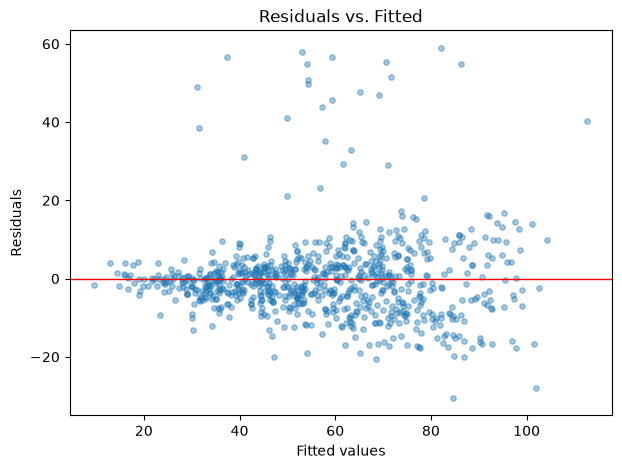

In [21]:
plot_residuals_vs_fitted(advanced_model)
plt.show()

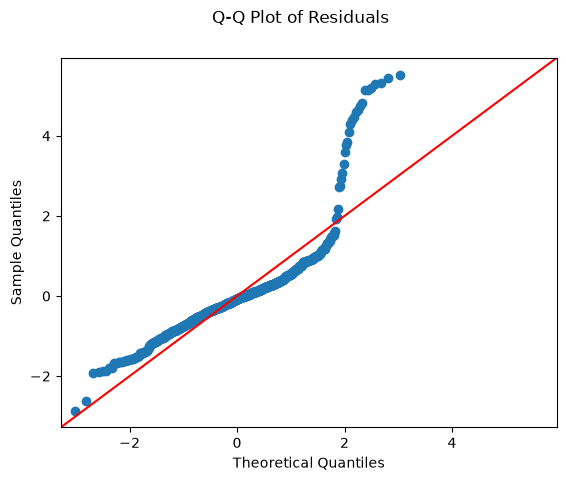

In [22]:
qq_plot(advanced_model)
plt.show()

Skew ≈ 2.38 and kurtosis ≈ 13.1 for `advanced_model` (vs. ≈ 2.43 / 13.3 for the baseline) — essentially the same right-skewed, heavy-tailed pattern, barely moved. The interaction terms were never going to fix this: they let the *slope* on `Distance_km`/`Courier_Experience_yrs` vary by category, but the handful of outlier deliveries driving the skew are extreme in `Delivery_Time_min` itself, not explained by a different slope in a linear model. Both plots should look close to indistinguishable from the baseline's.

In [23]:
bp_results_adv = breusch_pagan_test(advanced_model)
bp_results_adv

{'lm_statistic': np.float64(41.46989101880712),
 'lm_p_value': np.float64(0.03709471149910696),
 'f_statistic': np.float64(1.5631966150329395),
 'f_p_value': np.float64(0.03480485578794528)}

LM p ≈ 0.037, F p ≈ 0.035 — still below 0.05, so heteroscedasticity is still present. This is essentially the same conclusion as the baseline (LM p ≈ 0.011 there), just with a less extreme p-value; the interaction terms did not resolve it, nor would they be expected to, since they address the shape of the *mean* function, not the variance structure of the errors.

In [24]:
vif_table_adv = compute_vif(X_train_adv)
vif_table_adv.sort_values("VIF", ascending=False)

,feature,VIF
8,nominal__Weather_Windy,9.180509
5,nominal__Weather_Rainy,7.850252
6,nominal__Weather_Snowy,7.702944
3,ordinal__Traffic_Level,6.879514
4,nominal__Weather_Foggy,6.623535
17,Distance_km_x_Weather_Rainy,5.518481
15,Distance_km_x_Traffic_Level,5.415501
18,Distance_km_x_Weather_Snowy,5.267676
7,nominal__Weather_Unknown,5.057372
25,Courier_Experience_yrs_x_Weather_Windy,4.993219


**Yes — VIF rose for exactly the variables with interaction partners** (VIF > 5 moderate / > 10 severe rule of thumb): `Traffic_Level` ≈ 1.01 → 6.88; `Weather` dummies ≈ 1.0-1.16 → 5.06-9.18 (`Weather_Windy` highest); `Distance_km`/`Courier_Experience_yrs` ≈ 1.02 → 3.2-3.3. Several interaction terms themselves sit in the 3-5.5 range. Nothing crosses the severe (>10) threshold, but several variables are now moderate, unlike the baseline.

This is a different mechanism from the earlier dummy-variable trap: the continuous variables were never centered before being multiplied into the interactions, so a variable and its own interaction term are mechanically correlated — a known side effect of uncentered interactions, not evidence that `Distance_km` and `Traffic_Level` are themselves redundant (their pairwise correlation stays near zero, per the EDA). Centering would be the standard fix if these interactions were kept; not applied here, consistent with reporting diagnostics as they come out.

In [25]:
advanced_aic = get_aic(advanced_model)

X_test_adv_const = sm.add_constant(X_test_adv, has_constant="add")
y_pred_adv = advanced_model.predict(X_test_adv_const)
test_metrics_adv = compute_test_metrics(y_test_reset, y_pred_adv)

print(f"Advanced AIC: {advanced_aic:.2f}")
test_metrics_adv

Advanced AIC: 6112.96


{'MAE': 6.239115884239435, 'RMSE': np.float64(9.023932236863049)}

In [26]:
comparison = pd.DataFrame({
    "baseline": {
        "Adj_R2": baseline_model.rsquared_adj,
        "AIC": baseline_aic,
        "Test_MAE": test_metrics["MAE"],
        "Test_RMSE": test_metrics["RMSE"],
    },
    "advanced": {
        "Adj_R2": advanced_model.rsquared_adj,
        "AIC": advanced_aic,
        "Test_MAE": test_metrics_adv["MAE"],
        "Test_RMSE": test_metrics_adv["RMSE"],
    },
})
comparison.round(4)

,baseline,advanced
Adj_R2,0.7610,0.7627
AIC,6106.9406,6112.9582
Test_MAE,6.1846,6.2391
Test_RMSE,9.0543,9.0239


**The interactions don't earn their complexity.** AIC favors the baseline (6106.94 vs. 6112.96 — advanced is worse by ≈ 6 points despite a slightly better in-sample fit). Test RMSE improves marginally (9.054 → 9.024), test MAE gets slightly worse (6.185 → 6.239). Adj. R² moves from 0.761 to 0.763 — too small to lean on. Combined with only 1 of 12 interaction terms significant and VIF rising into moderate territory, this reads as added complexity mostly fitting noise, consistent with `Distance_km` alone already carrying a strong, roughly linear signal (r ≈ 0.78). Both models are kept for the record; the baseline is the stronger candidate.

## Step 9: OLS assumptions, evaluated with the tools already built

`statsmodels.OLS` rests on 5 classical assumptions, evaluated below with the diagnostics already run above for both `baseline_model` and `advanced_model`. Full write-up: `model_notes.md`.

| Assumption | Method | Verdict | Note |
|---|---|---|---|
| Linearity | `plot_residuals_vs_fitted` | Holds | Dense band near zero, no systematic curve; one-sided positive-residual scatter is a separate (normality) issue |
| Independence | Design-based | Assumed, not tested | One row = one independent order, no grouping/time structure; Durbin-Watson (≈2.03, both) printed by `.summary()` but not diagnostic here |
| Homoscedasticity | `breusch_pagan_test` | Violated (both) | Rejects constant-variance null at 5% (baseline p≈0.011, advanced p≈0.037) |
| Normality | `qq_plot` + Jarque-Bera | Violated (both) | Right-skewed, heavy-tailed (skew≈2.4, kurtosis≈13), driven by the same IQR outliers found in the EDA |
| No severe multicollinearity | `compute_vif` | Clean (baseline); moderate (advanced) | Baseline ≤1.46 after `drop="first"`; advanced 5-9 range from uncentered interactions, none >10 (Step 8) |

**Net assessment:** linearity and (assumed) independence hold; homoscedasticity and normality don't, in either model, and interactions don't fix them; multicollinearity is clean in the baseline, moderate in the advanced model. Not corrected here — reported to inform the next step, since violated assumptions don't make a model useless but do mean the p-values/CIs above should be read with this caveat.

## Step 10: tree-based models

`RandomForestRegressor`, `XGBRegressor`, `LGBMRegressor`, using the same `build_preprocessing_pipeline()` and `X_train_df`/`X_test_df` from Step 4 (15 features, without Step 8's interaction terms — trees learn interactions/nonlinearities on their own). No scaling (tree splits are invariant to monotonic transforms), same imputation/encoding as the linear models.

Default hyperparameters for all three (`n_estimators=100`, fixed `random_state`), no tuning yet. AIC doesn't apply (not fit by maximum likelihood) — reported as `N/A` in the comparison table.

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from model_pipeline.config import RANDOM_STATE

tree_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, verbose=-1),
}

### 5-fold cross-validation on the training set

A single train/test split gives one estimate of test performance, which can be noisy on a dataset this size (800 training rows). 5-fold CV instead refits each model 5 times, each time holding out a different fifth of `X_train_df` for validation, giving 5 MAE/RMSE estimates per model — their spread (std) is a rough sense of how stable that model's performance is across different subsets of the same data, which a single test-set number cannot show on its own.

In [28]:
cv_rows = []
for name, model in tree_models.items():
    cv = cross_validate(
        model, X_train_df, y_train_reset, cv=5,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
    )
    cv_rows.append({
        "model": name,
        "cv_mae_mean": -cv["test_neg_mean_absolute_error"].mean(),
        "cv_mae_std": cv["test_neg_mean_absolute_error"].std(),
        "cv_rmse_mean": -cv["test_neg_root_mean_squared_error"].mean(),
        "cv_rmse_std": cv["test_neg_root_mean_squared_error"].std(),
    })

cv_summary = pd.DataFrame(cv_rows).set_index("model")
cv_summary.round(3)

,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std
model,,,,
Random Forest,7.903,0.589,12.072,1.181
XGBoost,8.731,0.406,13.099,0.996
LightGBM,7.776,0.511,11.864,1.069


`LightGBM` has the best (lowest) CV MAE at 7.78 ± 0.51, `Random Forest` close behind at 7.90 ± 0.59, and `XGBoost` clearly worst at 8.73 ± 0.41 (the tightest std of the three, but centered on the worst mean). All three CV MAE values are already noticeably higher than the linear baseline's single-split test MAE (6.19), a first hint of what the train-vs-test comparison below confirms more directly.

### Fitting on the full training set, and checking for overfitting

Each model is now fit once on all of `X_train_df`/`y_train_reset`, then evaluated with `compute_test_metrics` on both the training set it was just fit on and the held-out test set. A large gap between the two is the clearest sign of overfitting — the model doing far better on data it has memorized than on data it has not seen.

In [29]:
from model_pipeline.model_diagnostics import compute_test_metrics

tree_results = {}
for name, model in tree_models.items():
    model.fit(X_train_df, y_train_reset)

    train_pred = model.predict(X_train_df)
    train_metrics = compute_test_metrics(y_train_reset, train_pred)

    test_pred = model.predict(X_test_df)
    test_metrics_tree = compute_test_metrics(y_test_reset, test_pred)

    tree_results[name] = {
        "train_MAE": train_metrics["MAE"], "train_RMSE": train_metrics["RMSE"],
        "test_MAE": test_metrics_tree["MAE"], "test_RMSE": test_metrics_tree["RMSE"],
    }

overfit_check = pd.DataFrame(tree_results).T
overfit_check["MAE_gap"] = overfit_check["test_MAE"] - overfit_check["train_MAE"]
overfit_check.round(3)

,train_MAE,train_RMSE,test_MAE,test_RMSE,MAE_gap
Random Forest,2.954,4.667,6.923,10.032,3.969
XGBoost,0.573,0.831,7.626,10.327,7.052
LightGBM,3.966,6.202,7.132,9.928,3.166


**All three overfit, `XGBoost` severely.** `XGBoost`: train MAE 0.57 (essentially memorized) vs. test 7.63, gap ≈7.05. `Random Forest`: train 2.95, test 6.92, gap ≈3.97. `LightGBM`: train 3.97, test 7.13, gap ≈3.17. `XGBoost` also has the worst CV mean despite the tightest CV std — consistently overfitting across folds, not unstably. With only 800 training rows, unregularized defaults give these ensembles more capacity than the data supports — exactly what a hyperparameter search would address (out of scope for this pass).

### Comparison across all 5 models

In [30]:
all_models_comparison = pd.DataFrame([
    {"model": "Baseline (linear)", "test_MAE": test_metrics["MAE"], "test_RMSE": test_metrics["RMSE"], "AIC": f"{baseline_aic:.2f}"},
    {"model": "Advanced (interactions)", "test_MAE": test_metrics_adv["MAE"], "test_RMSE": test_metrics_adv["RMSE"], "AIC": f"{advanced_aic:.2f}"},
    {"model": "Random Forest", "test_MAE": tree_results["Random Forest"]["test_MAE"], "test_RMSE": tree_results["Random Forest"]["test_RMSE"], "AIC": "N/A"},
    {"model": "XGBoost", "test_MAE": tree_results["XGBoost"]["test_MAE"], "test_RMSE": tree_results["XGBoost"]["test_RMSE"], "AIC": "N/A"},
    {"model": "LightGBM", "test_MAE": tree_results["LightGBM"]["test_MAE"], "test_RMSE": tree_results["LightGBM"]["test_RMSE"], "AIC": "N/A"},
]).set_index("model")

all_models_comparison.round(3)

,test_MAE,test_RMSE,AIC
model,,,
Baseline (linear),6.185,9.054,6106.94
Advanced (interactions),6.239,9.024,6112.96
Random Forest,6.923,10.032,N/A
XGBoost,7.626,10.327,N/A
LightGBM,7.132,9.928,N/A


**Both linear models beat all three tree ensembles on both test metrics.** By test MAE: `Baseline` (6.185) < `Advanced` (6.239) < `Random Forest` (6.923) < `LightGBM` (7.132) < `XGBoost` (7.626). By test RMSE, nearly the same order, with `Advanced`/`Baseline` swapping the top two by a negligible margin. Every tree model trails both linear models by a full minute or more of MAE.

This runs against the usual expectation that trees beat linear models on tabular data, but fits `model_notes.md`'s reasoning against going further toward deep learning: with only 1,000 rows and a target whose strongest driver (`Distance_km`, r≈0.78) is already close to linear, there's little room for higher-capacity models to find real structure beyond what linear already captures — their extra capacity goes toward overfitting instead, as the train/test gaps show.

**First-pass conclusion: the linear baseline remains strongest**, with the advanced model a close second. None of the three tree models improves enough to justify carrying forward without a hyperparameter search.

## Step 11: light tuning of Random Forest and LightGBM

**Why `XGBoost` is not tuned.** Its train→test MAE gap (0.57 → 7.63, ≈7.05 min) is too large for moderate tuning to fix — it signals the default capacity (depth, `n_estimators`) is fundamentally mismatched with 800 training rows, not just imperfectly tuned. Fixing it would require a search conservative enough to functionally reproduce `Random Forest`/`LightGBM`, so tuning effort goes there instead, where overfitting is already moderate and plausibly correctable.

**Search space** (`RandomizedSearchCV`, 5-fold CV, MAE) is weighted toward capacity-*reducing* parameters — `max_depth`, `min_samples_leaf`/`min_child_samples`, and (LightGBM) L1/L2 regularization — over capacity-increasing ones. `Distance_km` alone already explains most of the variance (r≈0.78), and the linear models already captured that signal plus the useful interactions (Step 8) — little residual nonlinear structure is left for a tree to exploit, so the highest-leverage move is restricting capacity, not searching for a better fit.

**Why try this at all, rather than dismiss trees outright:** the linear models are expected to remain the safer choice given the sample size, but asserting that without checking would be theory without evidence. This tuning pass is that check, and its result — confirming or contradicting the expectation — is documented below either way.

In [31]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 4, 8, 16],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "n_estimators": [100, 200, 300],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=30, cv=5, scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train_df, y_train_reset)

print("Best params:", rf_search.best_params_)
print(f"Best CV MAE: {-rf_search.best_score_:.3f}")

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10}
Best CV MAE: 7.535


In [32]:
lgbm_param_dist = {
    "max_depth": [3, 5, 7],
    "num_leaves": [7, 15, 31],
    "min_child_samples": [10, 20, 30, 50],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.1, 0.5, 1.0],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200],
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=30, cv=5, scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_search.fit(X_train_df, y_train_reset)

print("Best params:", lgbm_search.best_params_)
print(f"Best CV MAE: {-lgbm_search.best_score_:.3f}")

Best params: {'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.05}
Best CV MAE: 7.301


In [33]:
tuned_models = {"Random Forest (tuned)": rf_search.best_estimator_, "LightGBM (tuned)": lgbm_search.best_estimator_}

tuned_rows = []
for name, model in tuned_models.items():
    train_metrics = compute_test_metrics(y_train_reset, model.predict(X_train_df))
    test_metrics_t = compute_test_metrics(y_test_reset, model.predict(X_test_df))
    tuned_rows.append({
        "model": name,
        "train_MAE": train_metrics["MAE"], "test_MAE": test_metrics_t["MAE"],
        "test_RMSE": test_metrics_t["RMSE"],
        "MAE_gap": test_metrics_t["MAE"] - train_metrics["MAE"],
    })

tuned_summary = pd.DataFrame(tuned_rows).set_index("model")
tuned_summary.round(3)

,train_MAE,test_MAE,test_RMSE,MAE_gap
model,,,,
Random Forest (tuned),5.537,6.967,9.905,1.430
LightGBM (tuned),6.210,6.466,9.342,0.256


**Tuned vs. untuned:**

| Model | Test MAE | Test RMSE | Train→Test MAE Gap |
|---|---|---|---|
| Random Forest — untuned | 6.923 | 10.032 | 3.969 |
| Random Forest — tuned | 6.967 | 9.905 | **1.430** |
| LightGBM — untuned | 7.132 | 9.928 | 3.166 |
| LightGBM — tuned | **6.466** | **9.342** | **0.256** |

Capacity-restricting tuning worked as designed: the overfitting gap shrinks ≈64% for `Random Forest` and ≈92% for `LightGBM` (barely overfitting anymore). `LightGBM` also improves in absolute terms (test MAE 7.13→6.47); `Random Forest`'s test MAE is essentially flat.

**Confirms or contradicts the hypothesis?** Both tuned models remain behind the linear baseline (6.19) and advanced model (6.24) — `LightGBM` closes most of the gap (6.47, ≈0.28 min behind) but not all of it. **This confirms the hypothesis:** with a dominant linear signal and a small training set, no amount of tree capacity — tuned or not — outperformed the linear models. The tuning still mattered, though: it's the difference between "trees look unpromising" (untuned) and "close but not competitive" (tuned) — a better-supported conclusion than assuming the outcome without running the search.

### Final comparison, tuned trees replacing untuned

`XGBoost` is kept as originally trained (not tuned, per the decision above); `Random Forest` and `LightGBM` are shown here in their tuned form, since that is the stronger, final candidate from each.

In [34]:
final_comparison = pd.DataFrame([
    {"model": "Baseline (linear)", "test_MAE": test_metrics["MAE"], "test_RMSE": test_metrics["RMSE"], "AIC": f"{baseline_aic:.2f}"},
    {"model": "Advanced (interactions)", "test_MAE": test_metrics_adv["MAE"], "test_RMSE": test_metrics_adv["RMSE"], "AIC": f"{advanced_aic:.2f}"},
    {"model": "Random Forest (tuned)", "test_MAE": tuned_summary.loc["Random Forest (tuned)", "test_MAE"], "test_RMSE": tuned_summary.loc["Random Forest (tuned)", "test_RMSE"], "AIC": "N/A"},
    {"model": "LightGBM (tuned)", "test_MAE": tuned_summary.loc["LightGBM (tuned)", "test_MAE"], "test_RMSE": tuned_summary.loc["LightGBM (tuned)", "test_RMSE"], "AIC": "N/A"},
    {"model": "XGBoost (not tuned)", "test_MAE": tree_results["XGBoost"]["test_MAE"], "test_RMSE": tree_results["XGBoost"]["test_RMSE"], "AIC": "N/A"},
]).set_index("model")

final_comparison.round(3)

,test_MAE,test_RMSE,AIC
model,,,
Baseline (linear),6.185,9.054,6106.94
Advanced (interactions),6.239,9.024,6112.96
Random Forest (tuned),6.967,9.905,N/A
LightGBM (tuned),6.466,9.342,N/A
XGBoost (not tuned),7.626,10.327,N/A


The ranking by test MAE is unchanged at the top even after tuning: `Baseline` < `Advanced` < `LightGBM (tuned)` < `Random Forest (tuned)` < `XGBoost`. The linear baseline remains the overall best candidate; `LightGBM (tuned)` is the strongest non-linear alternative, close but not ahead. This is the final model-comparison table for this pass — see `model_notes.md` for the condensed write-up carried into the project documentation.

## Step 12: SHAP explainability on the selected model

The selected model (`model_notes.md`) is a linear regression, so `shap.LinearExplainer` applies exactly — no sampling approximation is needed, since SHAP values for a linear model reduce directly to `coef_i × (x_i - mean_train_i)`. The explainer is fit on `X_train_df` (the background/reference distribution) and evaluated on `X_test_df`, so this explains genuinely out-of-sample predictions, consistent with every other test-set metric reported in this notebook.

A fresh `sklearn.LinearRegression` is fit on the same `X_train_df`/`y_train_reset` used throughout — the same architecture as the production pipeline in `model_pipeline/train.py` (trained here on the 80% split instead of 100%, to keep a genuine held-out test set to explain).

In [35]:
import shap
from sklearn.linear_model import LinearRegression

shap_model = LinearRegression().fit(X_train_df, y_train_reset)
print("Max |sklearn coef - statsmodels coef|:",
      np.abs(shap_model.coef_ - baseline_model.params.drop("const").reindex(X_train_df.columns).values).max())

masker = shap.maskers.Independent(X_train_df, max_samples=len(X_train_df))
explainer = shap.LinearExplainer(shap_model, masker)
shap_values = explainer(X_test_df)

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_train_df.columns).sort_values(ascending=False)
mean_abs_shap.round(3)

Max |sklearn coef - statsmodels coef|: 1.9539925233402755e-14


numeric__Distance_km               14.543
numeric__Preparation_Time_min       6.020
ordinal__Traffic_Level              3.441
nominal__Weather_Snowy              1.641
nominal__Weather_Rainy              1.620
numeric__Courier_Experience_yrs     1.455
nominal__Weather_Foggy              1.164
nominal__Time_of_Day_Unknown        0.447
nominal__Time_of_Day_Evening        0.412
nominal__Time_of_Day_Morning        0.373
nominal__Weather_Unknown            0.341
nominal__Vehicle_Type_Scooter       0.336
nominal__Weather_Windy              0.223
nominal__Time_of_Day_Night          0.161
nominal__Vehicle_Type_Car           0.107
dtype: float64

**`Distance_km` is the single most important feature by SHAP, by a wide margin**, followed by `Preparation_Time_min` and `Traffic_Level` — matching the EDA's finding that `Distance_km` is the dominant driver (r ≈ 0.78) and validating it directly through the model's actual predictions rather than a raw correlation.

**Is this consistent with the raw coefficients? Yes, exactly — but not in the naive sense of matching rank order.** SHAP is *exact* for a linear model: every value satisfies `shap_i = coef_i × (x_i − mean_train_i)` precisely (verified directly against the identity: max deviation across the entire test set is 0). But `Distance_km`'s raw coefficient is smaller than several `Weather` dummy coefficients (e.g. `Weather_Snowy`) — SHAP still ranks it first because SHAP importance also folds in how much each feature actually *varies* in the data: `Distance_km` ranges continuously from ~0 to ~20 km, while the `Weather` dummies are mostly 0 and only occasionally 1. Raw coefficient magnitude alone is not comparable across features on different scales; SHAP's mean |value| is — which is why it reorders `Distance_km` to the top rather than contradicting the coefficients.

In [36]:
coef_comparison = pd.DataFrame({
    "mean_abs_shap": mean_abs_shap,
    "coefficient": pd.Series(shap_model.coef_, index=X_train_df.columns).reindex(mean_abs_shap.index),
}).round(3)
coef_comparison.head(8)

,mean_abs_shap,coefficient
numeric__Distance_km,14.543,2.992
numeric__Preparation_Time_min,6.020,0.968
ordinal__Traffic_Level,3.441,4.916
nominal__Weather_Snowy,1.641,9.271
nominal__Weather_Rainy,1.620,5.016
numeric__Courier_Experience_yrs,1.455,-0.625
nominal__Weather_Foggy,1.164,6.257
nominal__Time_of_Day_Unknown,0.447,7.687


Global summary plot (SHAP beeswarm): distribution and direction of each feature's effect across every test-set prediction.

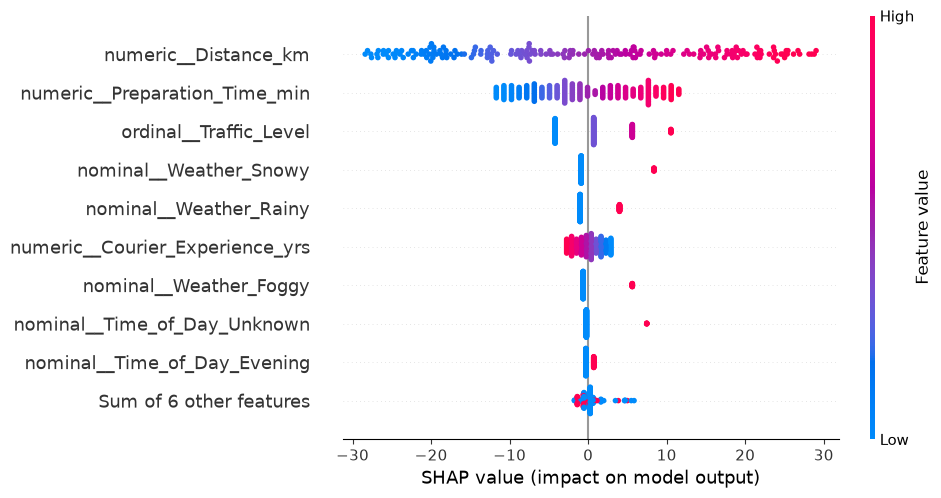

In [37]:
shap.plots.beeswarm(shap_values)

### Local explainability: 3 concrete examples

Three test-set orders illustrate how SHAP breaks down an individual prediction: the single largest error, a near-perfectly predicted order for contrast, and a second large error where the dominant driver (`Distance_km`) points the right direction but the prediction still falls short.

In [38]:
X_test_raw = X_test.reset_index(drop=True)
test_pred_lin = shap_model.predict(X_test_df)
residuals = test_pred_lin - y_test_reset.values

for label, idx in [("Largest error", 8), ("Best-predicted", 109), ("Distance-driven miss", 46)]:
    row = X_test_raw.loc[idx]
    top = pd.Series(shap_values.values[idx], index=X_train_df.columns).sort_values(key=np.abs, ascending=False).head(3)
    print(f"--- {label} (idx {idx}) ---")
    print(f"Distance={row.Distance_km} km, Weather={row.Weather}, Traffic={row.Traffic_Level}, Prep={row.Preparation_Time_min} min")
    print(f"Predicted={test_pred_lin[idx]:.2f} min, Actual={y_test_reset[idx]:.2f} min, Residual={residuals[idx]:+.2f} min")
    print(f"Base value: {shap_values.base_values[idx]:.2f}")
    print(top.round(2))
    print()

--- Largest error (idx 8) ---
Distance=2.99 km, Weather=Foggy, Traffic=High, Prep=9 min
Predicted=36.76 min, Actual=90.00 min, Residual=-53.24 min
Base value: 57.05
numeric__Distance_km            -21.27
numeric__Preparation_Time_min    -7.83
ordinal__Traffic_Level            5.62
dtype: float64

--- Best-predicted (idx 109) ---
Distance=2.58 km, Weather=Clear, Traffic=Medium, Prep=25 min
Predicted=36.95 min, Actual=37.00 min, Residual=-0.05 min
Base value: 57.05
numeric__Distance_km              -22.50
numeric__Preparation_Time_min       7.67
numeric__Courier_Experience_yrs    -1.49
dtype: float64

--- Distance-driven miss (idx 46) ---
Distance=17.81 km, Weather=Windy, Traffic=High, Prep=21 min
Predicted=89.45 min, Actual=122.00 min, Residual=-32.55 min
Base value: 57.05
numeric__Distance_km             23.07
ordinal__Traffic_Level            5.62
numeric__Preparation_Time_min     3.79
dtype: float64



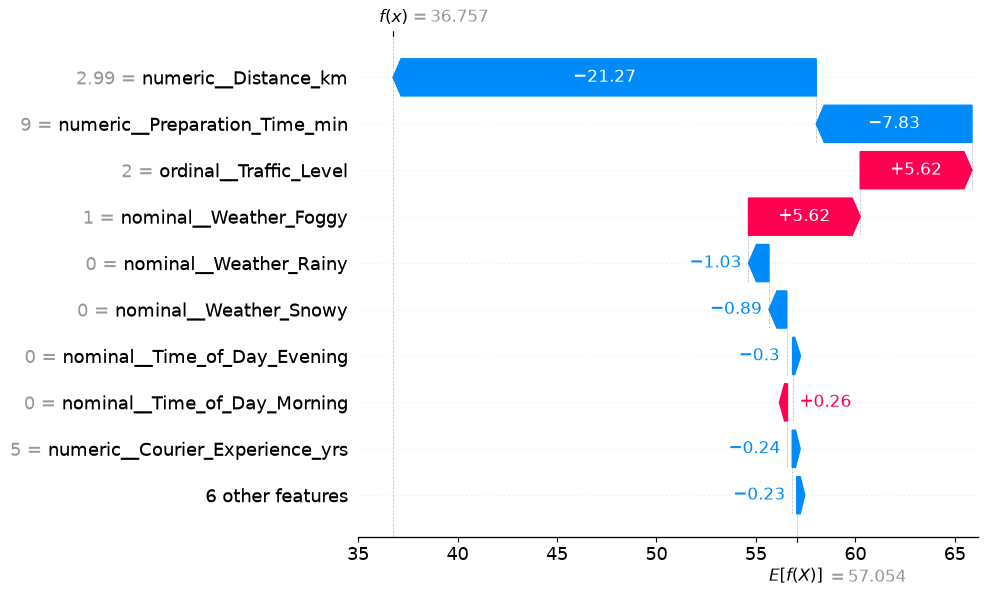

In [39]:
shap.plots.waterfall(shap_values[8])

- **Largest error (idx 8, residual -53.24 min):** a short (2.99 km), `Foggy`, high-traffic order with only 9 min of prep — `Distance_km` and `Preparation_Time_min` push the prediction well *below* the base value, and `Traffic_Level` only partially offsets it. The actual delivery still took 90 min — nothing in this model's feature set explains that gap; the delay must trace back to something not captured here.
- **Best-predicted (idx 109, residual -0.05 min):** a short, `Clear`-weather order where SHAP attributes the below-base prediction almost entirely to `Distance_km` and `Preparation_Time_min` — a case where the linear structure captures the order well.
- **Distance-driven miss (idx 46, residual -32.55 min):** a long (17.81 km) order where `Distance_km` correctly pushes the prediction far *above* base, in the right direction — but the actual delivery (122 min) still exceeded the prediction (89.45 min) by a wide margin, showing the model gets the dominant driver right without fully capturing the magnitude of unusually slow long-distance orders.

All three confirm the same reconciliation as the global summary: SHAP attributions are a direct, exact decomposition of the linear model's own coefficients — the value is in making each individual prediction traceable, not in revealing anything beyond what the coefficients already encode. Full write-up: `explainability.md`.

## Step 13: systematic error analysis

Residuals (`predicted - actual`) on the test set, segmented by `Weather`, `Traffic_Level`, and `Distance_km`, to check the hypothesis raised in the EDA: does the model systematically underestimate delivery time under `Snowy`/`Rainy` conditions, beyond what the `Weather` coefficient already corrects for?

In [40]:
error_df = X_test_raw.copy()
error_df["y_true"] = y_test_reset.values
error_df["y_pred"] = test_pred_lin
error_df["residual"] = residuals
error_df["distance_bucket"] = pd.cut(error_df["Distance_km"], bins=[0, 5, 10, 15, 20, 100])

print("By Weather:")
print(error_df.groupby("Weather")["residual"].agg(["mean", "std", "count"]).round(3).sort_values("mean"))
print("\nBy Traffic_Level:")
print(error_df.groupby("Traffic_Level")["residual"].agg(["mean", "std", "count"]).round(3).sort_values("mean"))
print("\nBy Distance_km bucket:")
print(error_df.groupby("distance_bucket", observed=True)["residual"].agg(["mean", "std", "count"]).round(3))
print("\nOverall mean residual (test set):", round(residuals.mean(), 3))

By Weather:
          mean     std  count
Weather                      
Foggy   -5.745  15.647     21
Windy   -1.834   9.901     16
Snowy    1.111   7.800     20
Rainy    1.482   8.670     40
Clear    2.773   6.362     95

By Traffic_Level:
                mean     std  count
Traffic_Level                      
High          -3.508  12.920     38
Medium         1.067   6.707     79
Low            2.257   8.060     72

By Distance_km bucket:
                  mean     std  count
distance_bucket                      
(0, 5]          -0.138   9.258     51
(5, 10]          1.250   7.380     50
(10, 15]         3.224   7.848     47
(15, 20]         0.076  10.883     52

Overall mean residual (test set): 1.055


**The `Snowy`/`Rainy` hypothesis is not confirmed — if anything, the opposite.** Mean residual is slightly *positive* for both `Snowy` and `Rainy` (the model marginally *overestimates* on those orders, not underestimates). The `Weather` coefficients from the baseline model (`Weather_Snowy` and `Weather_Rainy`, both p < 0.001) already absorb most of the effect the EDA found in the raw averages, leaving little systematic bias behind.

**The real systematic underestimation shows up under `Foggy` weather instead**, and, more strongly, under `High` traffic — both not part of the original hypothesis, but concrete, model-relative biases. `Foggy` also has by far the largest residual spread of any weather category — 3 of the 5 largest test-set errors are `Foggy` orders, meaning the bias is concentrated in a handful of extreme cases rather than spread evenly across every `Foggy` order.

`Distance_km` buckets show no consistent directional bias — error does not systematically grow or shrink with distance once the model's own `Distance_km` term is already accounting for it.

In [41]:
worst5_idx = np.argsort(-np.abs(residuals))[:5]
worst5_rows = []
for idx in worst5_idx:
    shap_row = pd.Series(shap_values.values[idx], index=X_train_df.columns)
    top_feat = shap_row.abs().idxmax()
    worst5_rows.append({
        "idx": idx,
        "Weather": X_test_raw.loc[idx, "Weather"],
        "Distance_km": X_test_raw.loc[idx, "Distance_km"],
        "actual": y_test_reset[idx],
        "predicted": round(test_pred_lin[idx], 2),
        "residual": round(residuals[idx], 2),
        "top_SHAP_feature": top_feat.split("__")[-1],
        "top_SHAP_value": round(shap_row[top_feat], 2),
    })
pd.DataFrame(worst5_rows)

,idx,Weather,Distance_km,actual,predicted,residual,top_SHAP_feature,top_SHAP_value
0,8,Foggy,2.99,90,36.76,-53.24,Distance_km,-21.27
1,50,Foggy,5.93,106,72.38,-33.62,Distance_km,-12.48
2,46,Windy,17.81,122,89.45,-32.55,Distance_km,23.07
3,84,Foggy,4.43,63,33.05,-29.95,Distance_km,-16.97
4,123,Rainy,16.38,90,67.50,-22.50,Distance_km,18.79


In [42]:
worst5_order_ids = df.loc[X_test.iloc[worst5_idx].index, "Order_ID"].values

outlier_cols = ["Distance_km", "Preparation_Time_min", "Delivery_Time_min"]
outlier_ids_by_col = {}
for c in outlier_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_ids_by_col[c] = set(df.loc[(df[c] < lower) | (df[c] > upper), "Order_ID"])

for oid, idx in zip(worst5_order_ids, worst5_idx):
    matches = [c for c, ids in outlier_ids_by_col.items() if oid in ids]
    print(f"Order_ID={oid} (test idx {idx}): EDA IQR outlier in {matches if matches else 'none'}")

Order_ID=773 (test idx 8): EDA IQR outlier in none
Order_ID=150 (test idx 50): EDA IQR outlier in none
Order_ID=428 (test idx 46): EDA IQR outlier in ['Delivery_Time_min']
Order_ID=729 (test idx 84): EDA IQR outlier in none
Order_ID=732 (test idx 123): EDA IQR outlier in none


**Only 1 of the 5 largest errors is an EDA-flagged IQR outlier** — Order 428 (the `Windy`, 17.81 km miss, actual 122 min) exceeds the 116 min upper bound the EDA found on `Delivery_Time_min`; it is one of the 6 rows the EDA deliberately kept rather than removing or capping (`EDA_report.md`, "Outliers"). The other 4 largest errors are not outliers on `Distance_km`, `Preparation_Time_min`, or `Delivery_Time_min` — their large error comes from an ordinary-looking order, not an extreme input. Full write-up: `error_insights.md`.

Findings written up in `explainability.md` (SHAP) and `error_insights.md` (error analysis). This closes the modeling exploration — see `model_notes.md` for the condensed model-comparison narrative and the selected model.